## Exercise 4

In this exercise, we will look at some color spaces like sRGB, XYZ, and Lab. We will make 3D scatterplots to see how colors are distributed, and then use MDS to create 2D embeddings. 

First, install and import the libraries we need.

In [159]:
# Installing requirements for the notebook
!pip install numpy matplotlib scikit-image scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [160]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from sklearn.manifold import MDS

## a) Sampling the Triangle
We need to generate around 100 colors on a triangle. The corners are the sRGB primary colors: Red (1,0,0), Green (0,1,0), and Blue (0,0,1). 

Since R + G + B = 1 in this triangle, we can use a nested loop to sample the points. If we divide the edge into 13 segments, we get exactly 105 points. This matches the 105 colors shown in the example figures perfectly.

In [161]:
colors_rgb = []
n = 13 # 13 intervals will yield exactly 105 points (14 * 15 / 2 = 105)

for i in range(n + 1):
    for j in range(n + 1 - i):
        k = n - i - j
        # calculating the ratio
        r = i / n
        g = j / n
        b = k / n
        colors_rgb.append([r, g, b])

colors_rgb = np.array(colors_rgb)
print(f"We generated {len(colors_rgb)} colors.")

We generated 105 colors.


## b) 3D Scatterplot in sRGB
Now we will create a 3D scatterplot for the sRGB points we generated. We use the RGB values of the points to color the markers in the plot.

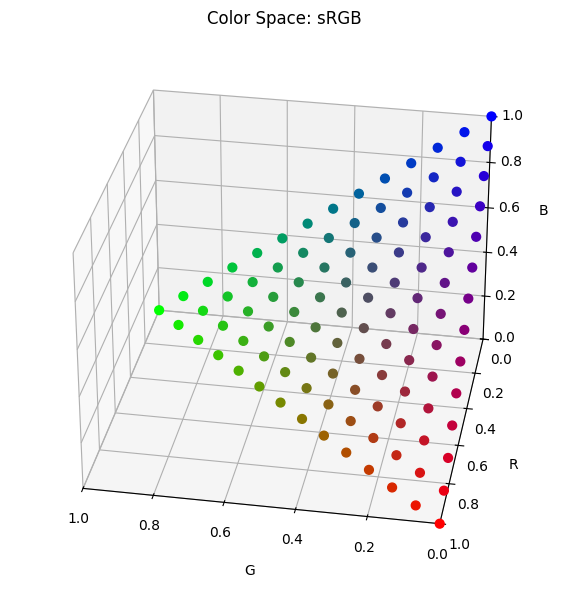

In [162]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plotted the points exactly with their true RGB colors (alpha=1.0 for solid colors)
ax.scatter(colors_rgb[:, 1], colors_rgb[:, 0], colors_rgb[:, 2], 
           c=colors_rgb, s=40, alpha=1.0)

# Properly label the axes
ax.set_xlabel('G', labelpad=10)
ax.set_ylabel('R', labelpad=10)
ax.set_zlabel('B', labelpad=10)

# Setting limits from 0.0 to 1.0 to match the exact bounds of the sRGB space cube
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

ax.set_title('Color Space: sRGB')

# "Reasonable 2D projection": We set the camera viewpoint to project the 3D plot neatly onto our 2D screen
ax.view_init(elev=30, azim=100)

plt.tight_layout()
plt.show()

## c) Convert to CIE XYZ and CIE Lab
Before we convert them, let's quickly explain what these spaces are:
- CIE XYZ: This is a basic color space that covers all colors human eyes can see. The 'Y' value simply shows how bright the color is.
- CIE Lab: This color space organizes colors exactly how our brains process them. If two colors look very different to us, they will be far apart in this space too. The 'L' stands for Lightness, while 'a' and 'b' define the actual color.

We can use skimage.color to convert our RGB colors into XYZ and Lab color spaces. Since skimage functions are originally designed to work with image arrays (which have dimensions like height, width, and color channels), we must first reshape our simple list of colors into a pseudo-image format before doing the conversion. Then we will plot them in 3D again to see the differences.

We also need to find the brightest and darkest primary colors. In the Lab color space, the 'L' axis represents Lightness, so we can check the highest and lowest points on this axis.

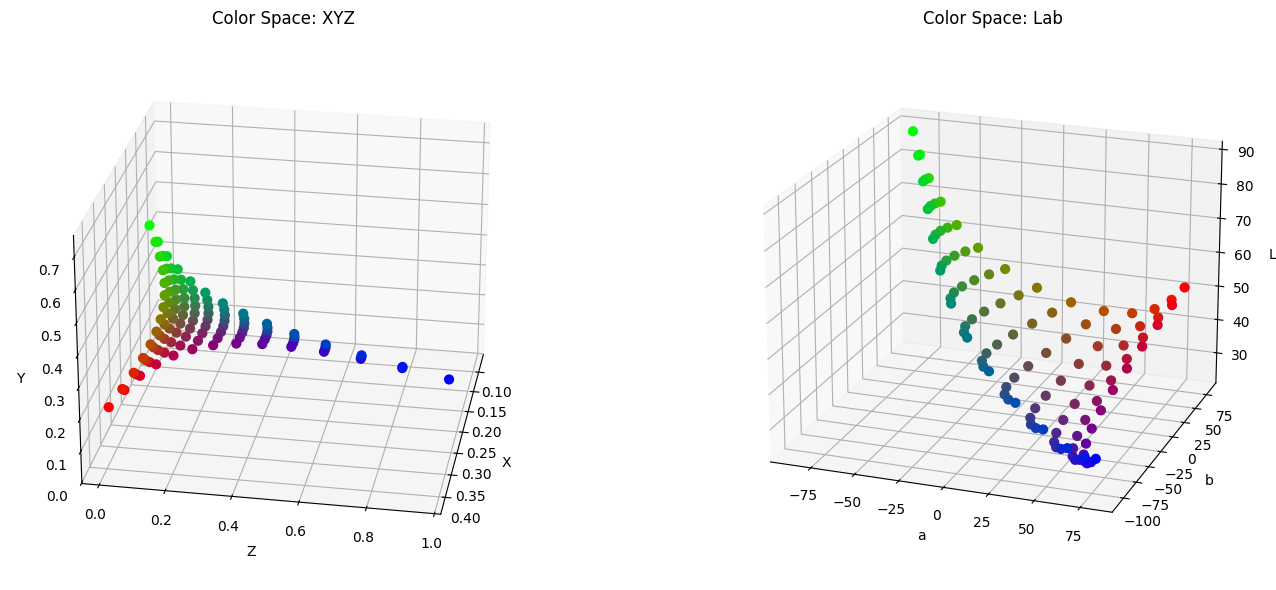

In [145]:
# Reshape the array because skimage expects an image format
colors_rgb_reshaped = colors_rgb.reshape(1, -1, 3)

# Convert colors to XYZ and Lab
colors_xyz = color.rgb2xyz(colors_rgb_reshaped).reshape(-1, 3)
colors_lab = color.rgb2lab(colors_rgb_reshaped).reshape(-1, 3)

fig = plt.figure(figsize=(15, 6))

# Plotting the CIE XYZ Color Space
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(colors_xyz[:, 0], colors_xyz[:, 2], colors_xyz[:, 1], 
            c=colors_rgb, s=40, alpha=1.0) # Used true colors by setting c=colors_rgb

# Labeling XYZ axes
ax1.set_xlabel('X', labelpad=5)
ax1.set_ylabel('Z', labelpad=5)
ax1.set_zlabel('Y', labelpad=5)
ax1.set_title('Color Space: XYZ')
# Adjusting the view angle to closely approximate the reference figure
ax1.view_init(elev=25, azim=10)

# Plotting the CIE Lab Color Space
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(colors_lab[:, 1], colors_lab[:, 2], colors_lab[:, 0], 
            c=colors_rgb, s=40, alpha=1.0) # Used true colors by setting c=colors_rgb

# Labeling Lab axes (Lightness L is the vertical axis)
ax2.set_xlabel('a', labelpad=5)
ax2.set_ylabel('b', labelpad=5)
ax2.set_zlabel('L', labelpad=5)
ax2.set_title('Color Space: Lab')
# Adjusting the view angle for optimal representation of Lab coordinates
ax2.view_init(elev=20, azim=-70)

plt.tight_layout()
plt.show()

Comment on Brightness:

Looking at the L (Lightness) axis of the Lab plot, the green corner is the highest point. So, green is the brightest primary color. The blue corner is the lowest on the L axis, so blue is the darkest primary color. 

Also, it's interesting to see that when Red and Blue mix (the line connecting the R and B corners), the lightness drops even further down before going back up depending on the color ratio. So that specific magenta/purple region is the darkest part of the whole triangle in terms of perceptual lightness.

## d) 2D Embeddings using MDS
Finally, we apply Multidimensional Scaling (MDS) utilizing sklearn to embed these 3D points into a simple 2D space. We will perform this transformation for all three spaces (sRGB, XYZ, and Lab) and observe how their basic shapes change.

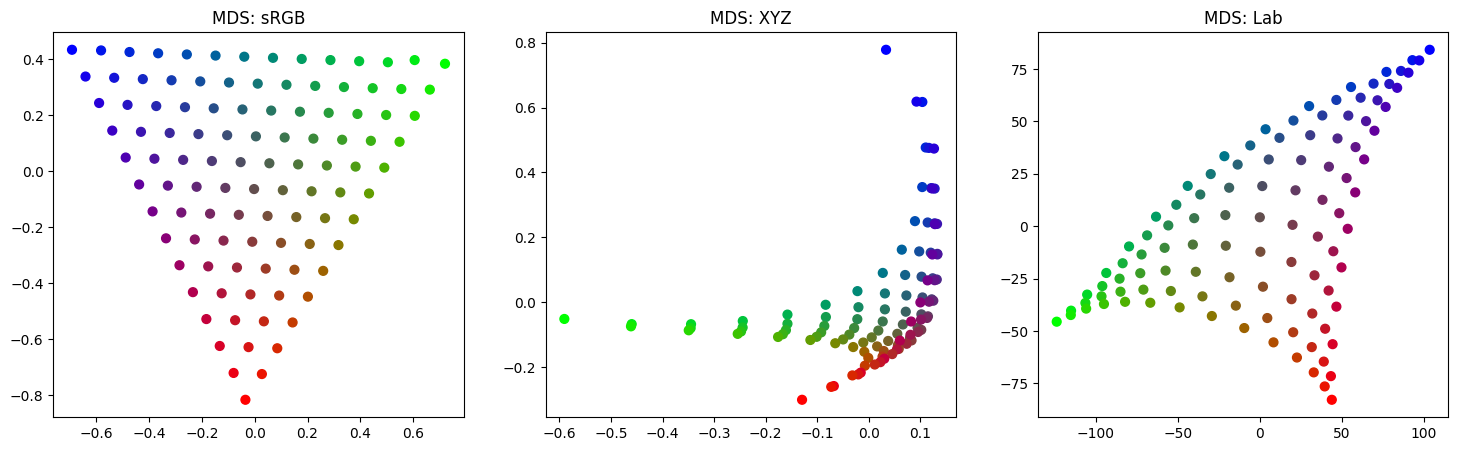

In [158]:
# Passing n_init and init parameters explicitly to suppress FutureWarnings from sklearn
mds = MDS(n_components=2, random_state=1, n_init=4, init='random')

mds_rgb = mds.fit_transform(colors_rgb)
mds_xyz = mds.fit_transform(colors_xyz)
mds_lab = mds.fit_transform(colors_lab)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plotting the MDS results
ax1.scatter(-mds_rgb[:, 1], -mds_rgb[:, 0], c=colors_rgb, s=40)
ax1.set_title('MDS: sRGB')

ax2.scatter(-mds_xyz[:, 1], -mds_xyz[:, 0], c=colors_rgb, s=40)
ax2.set_title('MDS: XYZ')

ax3.scatter(-mds_lab[:, 1], -mds_lab[:, 0], c=colors_rgb, s=40)
ax3.set_title('MDS: Lab')

plt.show()

Comment on Resulting Shapes:
- sRGB: The resulting 2D embedding maintains a shape very similar to a regular triangle. Since the original points were uniformly sampled on a planar triangle, MDS easily preserves these distances in 2D.
- XYZ: The shape is noticeably stretched and slightly compressed compared to the sRGB plot. The mapping to XYZ space alters the distances between colors compared to human vision logic, which causes the uniform grid to somewhat bend.
- Lab: The Lab embedding shows a significantly curved and stretched shape. The Lab color space is specifically designed to be perceptually uniform. When MDS attempts to maintain those "perceptual distances" on a basic 2D plane, it turns the straight edges of our original RGB triangle into highly non-linear, curved boundaries.